# Activation Functions

**Math prerequisites:** `00_math/calculus_chain_rule.ipynb`  
**Code prerequisites:** `01_foundations/backpropagation.ipynb`

**Why this notebook matters:** The choice of activation function determines whether:
- Gradients vanish or explode (training stability)
- The network can learn non-linear functions (expressivity)
- Dead neurons appear (ReLU dying)
- Outputs are interpretable as probabilities (output layer)

**What you will build:**
- Every activation from scratch in NumPy with full derivative proofs
- Animated comparison showing function shape and gradient behaviour
- Gradient flow experiments: sigmoid vs tanh vs ReLU vs GELU across depth
- Dead neuron detection and diagnosis
- Output activation selection guide by task type

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/01_foundations/activation_functions.ipynb)

---

## Table of Contents
1. [Why Activations Exist — the non-linearity argument](#1-why-activations)
2. [Sigmoid](#2-sigmoid)
3. [Tanh](#3-tanh)
4. [ReLU and Variants](#4-relu)
5. [GELU, SiLU, Swish](#5-gelu-silu)
6. [Output Activations by Task](#6-output-activations)
7. [Comparison — all activations side by side](#7-comparison)
8. [Gradient Flow Experiments](#8-gradient-flow)
9. [The Dead Neuron Problem](#9-dead-neurons)
10. [PyTorch Implementation and Custom Activations](#10-pytorch)
11. [Debugging Section](#11-debugging)
12. [Exercises](#12-exercises)


## Setup

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')

# Shared x-range for all plots
x_range = np.linspace(-4, 4, 400)


PyTorch 2.10.0+cpu | device: cpu


## 1. Why Activations Exist — The Non-Linearity Argument

Without activation functions, any stack of linear layers collapses to a single linear transformation:

$$W^{(2)}(W^{(1)}\mathbf{x} + \mathbf{b}^{(1)}) + \mathbf{b}^{(2)} = \underbrace{(W^{(2)}W^{(1)})}_{W'} \mathbf{x} + \underbrace{(W^{(2)}\mathbf{b}^{(1)} + \mathbf{b}^{(2)})}_{\mathbf{b}'} = W'\mathbf{x} + \mathbf{b}'$$

Ten linear layers = one linear layer. Depth is useless without non-linearity.

### What activations must provide

1. **Non-linearity** — the obvious one
2. **Differentiability** — for backpropagation (almost everywhere is enough for ReLU)
3. **Non-saturation** — gradients should not vanish for typical input ranges
4. **Computational efficiency** — called millions of times per training step
5. **Biological plausibility** (optional, historical motivation)

### Where activations are placed

| Position | What to use | Why |
|---|---|---|
| Hidden layers | ReLU (default), GELU (transformers) | Non-saturating, efficient |
| Output (binary classification) | Sigmoid | Maps to (0,1) = probability |
| Output (multi-class) | Softmax | Maps to probability distribution |
| Output (regression) | None (linear) | Unbounded prediction |
| Output (bounded regression) | Tanh | Maps to (-1, 1) |


In [18]:
# Prove: stacking linear layers = one linear layer
torch.manual_seed(0)
x_demo = torch.randn(5, 4)

# Deep linear network
linear_deep = nn.Sequential(
    nn.Linear(4, 8), nn.Linear(8, 8), nn.Linear(8, 4), nn.Linear(4, 2)
)

# Equivalent single linear layer
# Compute the effective W and b
with torch.no_grad():
    W_eff = linear_deep[3].weight @ linear_deep[2].weight @ \
            linear_deep[1].weight @ linear_deep[0].weight
    # b_eff = W3(W2(W1 b0 + b1) + b2) + b3 — simplified for demonstration

    out_deep   = linear_deep(x_demo)
    out_direct = x_demo @ W_eff.T  # + bias terms (omitted for clarity)

print('Deep linear network output:')
print(out_deep[:2].detach().numpy().round(4))

# Now with activation
nonlinear = nn.Sequential(
    nn.Linear(4, 8), nn.ReLU(),
    nn.Linear(8, 8), nn.ReLU(),
    nn.Linear(8, 4), nn.ReLU(),
    nn.Linear(4, 2)
)

with torch.no_grad():
    out_nonlinear = nonlinear(x_demo)

print('Non-linear network output (different — not collapsible):')
print(out_nonlinear[:2].detach().numpy().round(4))

print('\nKey: the non-linear network cannot be reduced to a single linear layer.')


Deep linear network output:
[[-0.4487  0.2235]
 [-0.3955  0.1477]]
Non-linear network output (different — not collapsible):
[[0.053  0.5609]
 [0.0779 0.5807]]

Key: the non-linear network cannot be reduced to a single linear layer.


## 2. Sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Derivative (elegant — self-referential):**

$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

**Proof:**
$$\sigma'(z) = \frac{d}{dz}(1 + e^{-z})^{-1} = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z) \cdot (1 - \sigma(z))$$

**Properties:**
- Output range: $(0, 1)$ → interpretable as probability
- Smooth and differentiable everywhere
- **Saturates** at $|z| \gg 0$: $\sigma'(z) \to 0$ → **vanishing gradients**
- Max derivative: $\sigma'(0) = 0.25$ → gradient is attenuated by at least $4\times$ per layer
- Output **not zero-centred** (always positive) → gradient updates always have the same sign → zigzag optimisation

**When to use:** Output layer for binary classification only. Avoid in hidden layers.


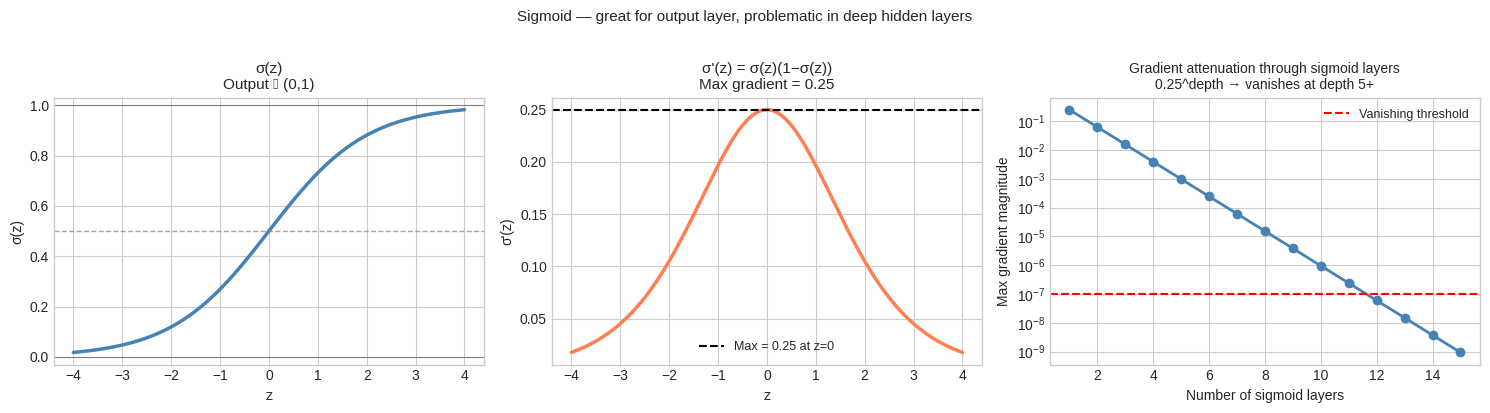

σ'(1.5) — analytical: 0.14914645  numerical: 0.14914645  match: True


In [19]:
# Sigmoid — full implementation and analysis
def sigmoid(z):       return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def sigmoid_prime(z): s = sigmoid(z); return s * (1 - s)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Function
axes[0].plot(x_range, sigmoid(x_range), color='steelblue', lw=2.5)
axes[0].axhline(0.5, color='gray', lw=1, linestyle='--', alpha=0.7)
axes[0].axhline(0,   color='gray', lw=0.8)
axes[0].axhline(1,   color='gray', lw=0.8)
axes[0].set_title('σ(z)\nOutput ∈ (0,1)', fontsize=11)
axes[0].set_xlabel('z'); axes[0].set_ylabel('σ(z)')

# Derivative
axes[1].plot(x_range, sigmoid_prime(x_range), color='coral', lw=2.5)
axes[1].axhline(0.25, color='black', lw=1.5, linestyle='--',
                label='Max = 0.25 at z=0')
axes[1].set_title("σ'(z) = σ(z)(1−σ(z))\nMax gradient = 0.25", fontsize=11)
axes[1].set_xlabel('z'); axes[1].set_ylabel("σ'(z)")
axes[1].legend(fontsize=9)

# Saturation demo: gradient through n sigmoid layers
depths = range(1, 16)
grad_products = [0.25**d for d in depths]
axes[2].semilogy(depths, grad_products, 'o-', color='steelblue', lw=2)
axes[2].axhline(1e-7, color='red', lw=1.5, linestyle='--', label='Vanishing threshold')
axes[2].set_title('Gradient attenuation through sigmoid layers\n0.25^depth → vanishes at depth 5+', fontsize=10)
axes[2].set_xlabel('Number of sigmoid layers')
axes[2].set_ylabel('Max gradient magnitude')
axes[2].legend(fontsize=9)

plt.suptitle('Sigmoid — great for output layer, problematic in deep hidden layers', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Verify derivative
z_test = 1.5
numerical = (sigmoid(z_test+1e-7) - sigmoid(z_test-1e-7)) / (2e-7)
analytical = sigmoid_prime(z_test)
print(f'σ\'({z_test}) — analytical: {analytical:.8f}  numerical: {numerical:.8f}  match: {np.isclose(analytical, numerical)}')


## 3. Tanh

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = 2\sigma(2z) - 1$$

**Derivative:**

$$\tanh'(z) = 1 - \tanh^2(z)$$

**Proof:**
$$\tanh'(z) = \frac{(e^z+e^{-z})^2 - (e^z-e^{-z})^2}{(e^z+e^{-z})^2} = 1 - \frac{(e^z-e^{-z})^2}{(e^z+e^{-z})^2} = 1 - \tanh^2(z)$$

**Properties:**
- Output range: $(-1, 1)$ → **zero-centred** (advantage over sigmoid)
- Max derivative: $\tanh'(0) = 1$ → 4× better gradient flow than sigmoid
- Still **saturates** for $|z| \gg 0$ → still vanishes in very deep networks
- Relationship to sigmoid: $\tanh(z) = 2\sigma(2z) - 1$

**When to use:** RNN/LSTM hidden states (zero-centred helps), output for bounded regression.


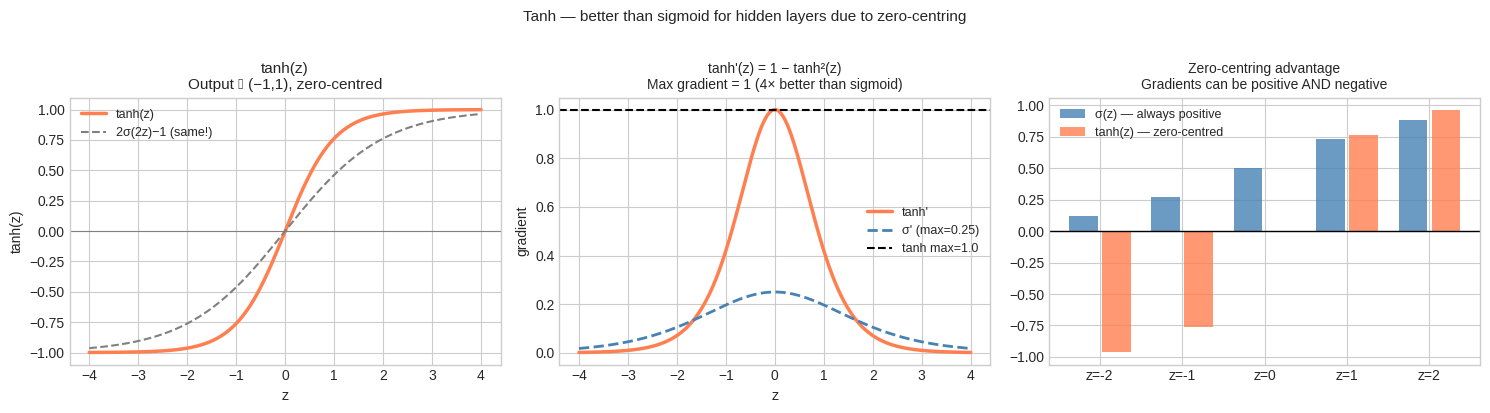

In [20]:
# Tanh — full implementation and analysis
def tanh(z):       return np.tanh(z)
def tanh_prime(z): return 1 - np.tanh(z)**2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x_range, tanh(x_range),       color='coral', lw=2.5, label='tanh(z)')
axes[0].plot(x_range, sigmoid(x_range)*2-1, color='gray', lw=1.5, linestyle='--',
             label='2σ(2z)−1 (same!)')
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_title('tanh(z)\nOutput ∈ (−1,1), zero-centred', fontsize=11)
axes[0].set_xlabel('z'); axes[0].set_ylabel('tanh(z)')
axes[0].legend(fontsize=9)

axes[1].plot(x_range, tanh_prime(x_range),     color='coral', lw=2.5, label="tanh'")
axes[1].plot(x_range, sigmoid_prime(x_range),   color='steelblue', lw=2, linestyle='--',
             label="σ' (max=0.25)")
axes[1].axhline(1.0, color='black', lw=1.5, linestyle='--', label='tanh max=1.0')
axes[1].set_title("tanh'(z) = 1 − tanh²(z)\nMax gradient = 1 (4× better than sigmoid)", fontsize=10)
axes[1].set_xlabel('z'); axes[1].set_ylabel('gradient')
axes[1].legend(fontsize=9)

# Zero-centring advantage
axes[2].set_title('Zero-centring advantage\nGradients can be positive AND negative', fontsize=10)
z_vals = np.array([-2, -1, 0, 1, 2], dtype=float)
sig_out = sigmoid(z_vals)
tanh_out = tanh(z_vals)
x_pos = np.arange(len(z_vals))
axes[2].bar(x_pos-0.2, sig_out,  0.35, label='σ(z) — always positive', color='steelblue', alpha=0.8)
axes[2].bar(x_pos+0.2, tanh_out, 0.35, label='tanh(z) — zero-centred',  color='coral',     alpha=0.8)
axes[2].axhline(0, color='black', lw=1)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f'z={v:.0f}' for v in z_vals])
axes[2].legend(fontsize=9)

plt.suptitle('Tanh — better than sigmoid for hidden layers due to zero-centring', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 4. ReLU and Variants

### ReLU (Rectified Linear Unit)

$$\text{ReLU}(z) = \max(0, z) = \begin{cases} z & z > 0 \\ 0 & z \leq 0 \end{cases}$$

$$\text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z < 0 \end{cases} \quad \text{(subgradient = 0 at z=0)}$$

**Properties:**
- **No vanishing gradient** for positive inputs: derivative = 1 always
- **Sparse activation**: ~50% of neurons output 0 at any given time (efficient)
- Computationally trivial: just a threshold
- **Dying ReLU**: neurons can permanently output 0 if all inputs are negative
- Not zero-centred (output always ≥ 0)

### Leaky ReLU

$$\text{LeakyReLU}(z) = \begin{cases} z & z > 0 \\ \alpha z & z \leq 0 \end{cases} \quad \alpha = 0.01$$

Fixes dying ReLU by allowing a small gradient for negative inputs.

### ELU (Exponential Linear Unit)

$$\text{ELU}(z) = \begin{cases} z & z > 0 \\ \alpha(e^z - 1) & z \leq 0 \end{cases}$$

Smooth negative region, zero-centred mean activations, better than Leaky ReLU in some settings.

### PReLU (Parametric ReLU)

Like Leaky ReLU but $\alpha$ is a **learnable parameter**:

$$\text{PReLU}(z) = \begin{cases} z & z > 0 \\ \alpha z & z \leq 0 \end{cases} \quad \alpha \text{ learned}$$


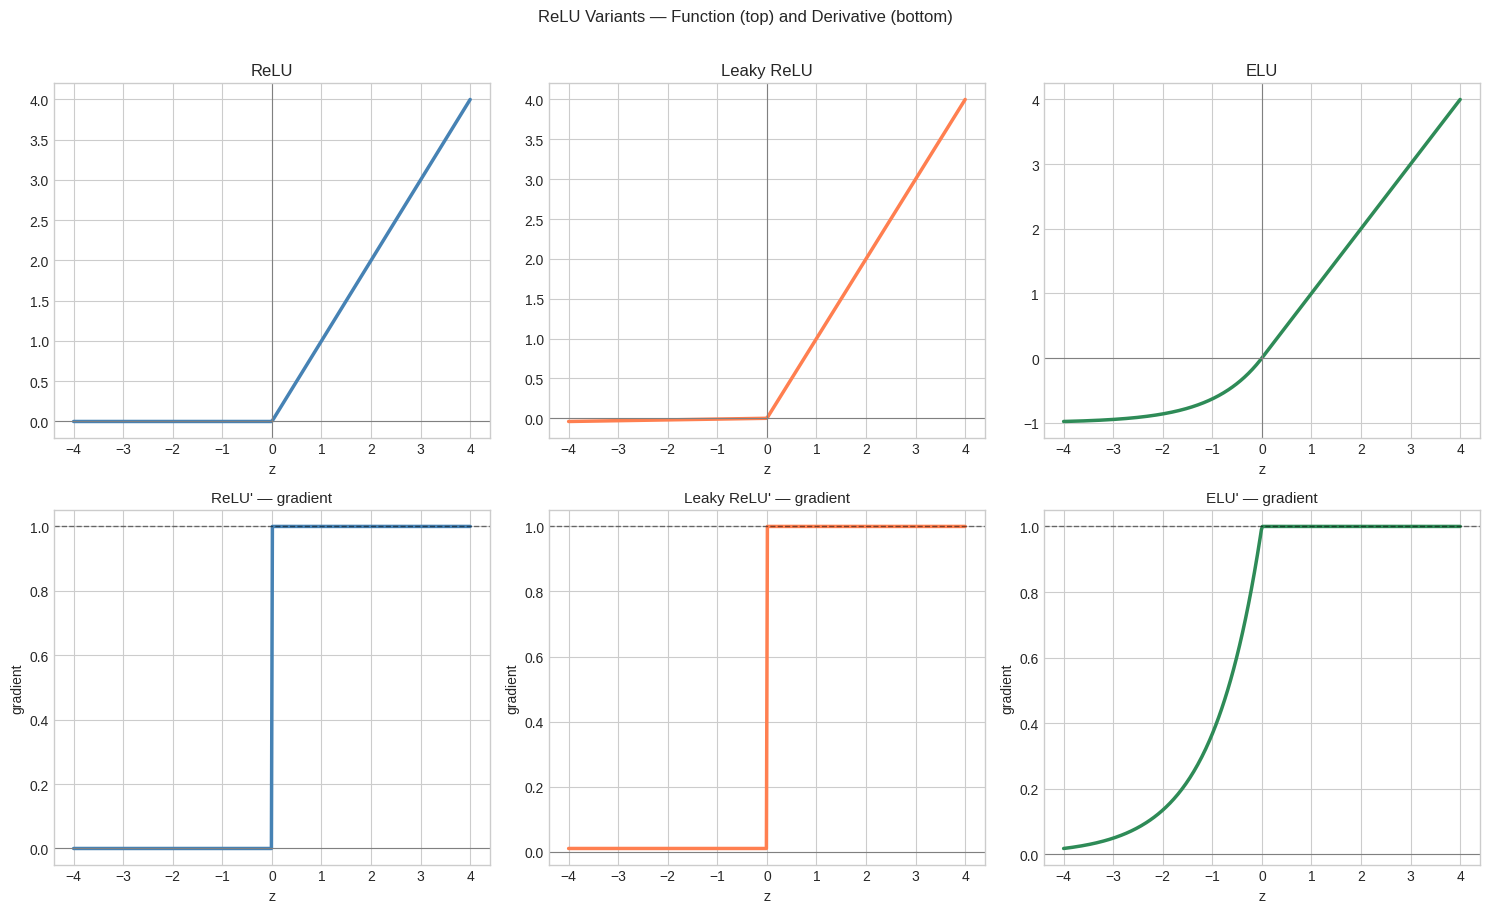

Activation              Range   Max grad   Zero-centred  Dying issue
----------------------------------------------------------------------
ReLU                  [0, +∞)    1 (z>0)             No          Yes
Leaky ReLU           (-∞, +∞)    1 (z>0)             No           No
ELU                  (-α, +∞)    1 (z>0)           ~Yes           No
Sigmoid                (0, 1)       0.25             No           No
Tanh                  (-1, 1)        1.0            Yes           No


In [21]:
def relu(z):               return np.maximum(0, z)
def relu_prime(z):         return (z > 0).astype(float)
def leaky_relu(z, a=0.01): return np.where(z > 0, z, a*z)
def leaky_relu_prime(z, a=0.01): return np.where(z > 0, 1.0, a)
def elu(z, a=1.0):         return np.where(z > 0, z, a*(np.exp(np.minimum(z,0))-1))
def elu_prime(z, a=1.0):   return np.where(z > 0, 1.0, a*np.exp(np.minimum(z,0)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

acts = [
    ('ReLU',       relu,        relu_prime,        'steelblue'),
    ('Leaky ReLU', leaky_relu,  leaky_relu_prime,  'coral'),
    ('ELU',        elu,         elu_prime,         'seagreen'),
]

for col, (name, f, df, color) in enumerate(acts):
    y_f  = f(x_range)
    y_df = df(x_range)

    # Function
    axes[0, col].plot(x_range, y_f, color=color, lw=2.5)
    axes[0, col].axhline(0, color='gray', lw=0.8)
    axes[0, col].axvline(0, color='gray', lw=0.8)
    axes[0, col].set_title(f'{name}', fontsize=12)
    axes[0, col].set_xlabel('z')

    # Derivative
    axes[1, col].plot(x_range, y_df, color=color, lw=2.5)
    axes[1, col].axhline(0, color='gray', lw=0.8)
    axes[1, col].axhline(1, color='black', lw=1, linestyle='--', alpha=0.5)
    axes[1, col].set_title(f"{name}' — gradient", fontsize=11)
    axes[1, col].set_xlabel('z'); axes[1, col].set_ylabel('gradient')

plt.suptitle('ReLU Variants — Function (top) and Derivative (bottom)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Comparison table
print(f'{'Activation':<14} {'Range':>14} {'Max grad':>10} {'Zero-centred':>14} {'Dying issue':>12}')
print('-' * 70)
for name, rng, mg, zc, dying in [
    ('ReLU',       '[0, +∞)',     '1 (z>0)',  'No',  'Yes'),
    ('Leaky ReLU', '(-∞, +∞)',   '1 (z>0)',  'No',  'No'),
    ('ELU',        '(-α, +∞)',   '1 (z>0)',  '~Yes','No'),
    ('Sigmoid',    '(0, 1)',      '0.25',     'No',  'No'),
    ('Tanh',       '(-1, 1)',     '1.0',      'Yes', 'No'),
]:
    print(f'{name:<14} {rng:>14} {mg:>10} {zc:>14} {dying:>12}')


## 5. GELU, SiLU, and Swish — Modern Activations

### GELU (Gaussian Error Linear Unit)

$$\text{GELU}(z) = z \cdot \Phi(z) = z \cdot P(X \leq z) \quad X \sim \mathcal{N}(0,1)$$

where $\Phi$ is the standard Gaussian CDF. Approximation (faster):

$$\text{GELU}(z) \approx 0.5z\left(1 + \tanh\left[\sqrt{\frac{2}{\pi}}(z + 0.044715z^3)\right]\right)$$

**Intuition:** GELU stochastically gates the input — the neuron output is $z$ with probability $\Phi(z)$ and $0$ with probability $1-\Phi(z)$. Unlike ReLU (hard gate), GELU is a soft, smooth gate.

**Used in:** BERT, GPT-2/3, ViT, most modern transformer architectures.

### SiLU (Sigmoid Linear Unit) / Swish

$$\text{SiLU}(z) = z \cdot \sigma(z)$$

$$\text{SiLU}'(z) = \sigma(z) + z \cdot \sigma(z)(1 - \sigma(z)) = \sigma(z)(1 + z(1-\sigma(z)))$$

**Properties shared by GELU and SiLU:**
- Smooth, differentiable everywhere
- Non-monotonic: slightly negative for $z \approx -1.3$
- Unbounded above, bounded below
- Empirically outperform ReLU on NLP tasks
- More expensive to compute than ReLU

### Mish

$$\text{Mish}(z) = z \cdot \tanh(\ln(1 + e^z))$$

Smooth, non-monotonic. Popular in computer vision (YOLOv4).


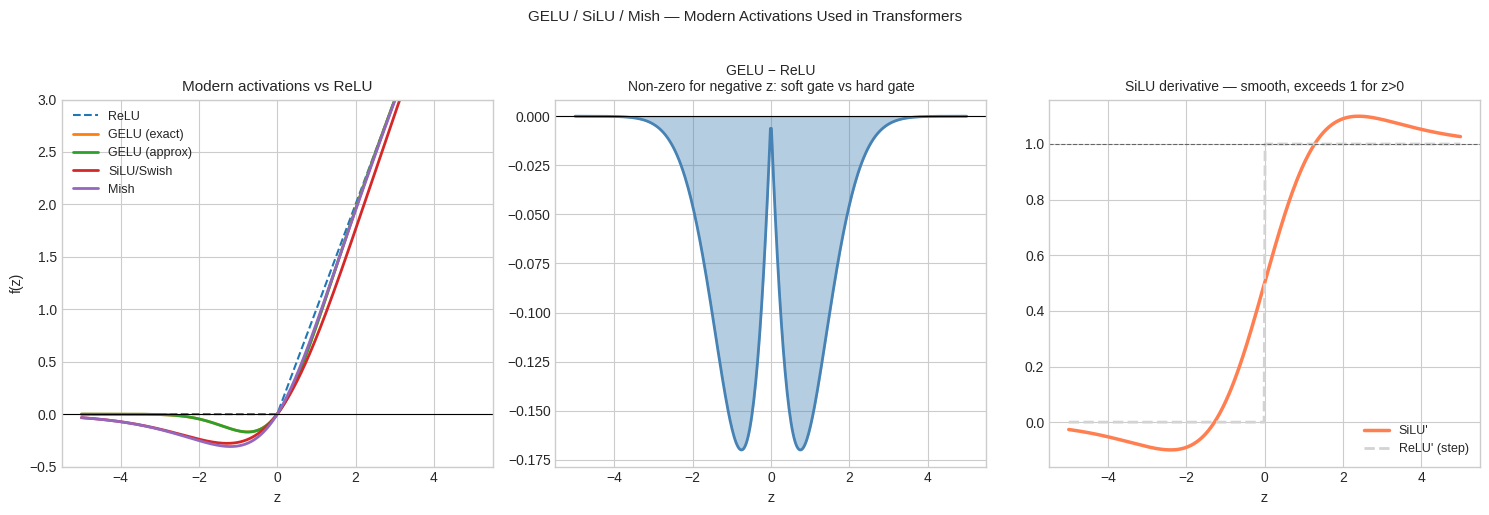

Max |GELU_exact - GELU_approx| = 0.000473  (negligible)


In [22]:
from scipy.special import erf

def gelu(z):
    # Exact GELU using Gaussian CDF
    return z * 0.5 * (1 + erf(z / np.sqrt(2)))

def gelu_approx(z):
    # FastGELU approximation used in BERT/GPT
    return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

def silu(z):   return z * sigmoid(z)   # also called Swish

def silu_prime(z):
    s = sigmoid(z)
    return s * (1 + z * (1 - s))

def mish(z):   return z * np.tanh(np.log1p(np.exp(np.clip(z, -20, 20))))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# All modern activations
x_m = np.linspace(-5, 5, 400)
ax = axes[0]
for f, name, color in [
    (relu,       'ReLU',         'lightgray'),
    (gelu,       'GELU (exact)', 'steelblue'),
    (gelu_approx,'GELU (approx)','royalblue'),
    (silu,       'SiLU/Swish',   'coral'),
    (mish,       'Mish',         'seagreen'),
]:
    ax.plot(x_m, f(x_m), label=name, lw=2 if name!='ReLU' else 1.5,
            linestyle='--' if name=='ReLU' else '-')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Modern activations vs ReLU', fontsize=11)
ax.set_xlabel('z'); ax.set_ylabel('f(z)')
ax.set_ylim(-0.5, 3); ax.legend(fontsize=9)

# GELU vs ReLU difference
ax2 = axes[1]
ax2.fill_between(x_m, gelu(x_m) - relu(x_m), alpha=0.4, color='steelblue')
ax2.plot(x_m, gelu(x_m) - relu(x_m), color='steelblue', lw=2)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('GELU − ReLU\nNon-zero for negative z: soft gate vs hard gate', fontsize=10)
ax2.set_xlabel('z')

# SiLU derivative
ax3 = axes[2]
ax3.plot(x_m, silu_prime(x_m),   color='coral',     lw=2.5, label="SiLU'")
ax3.plot(x_m, relu_prime(x_m),   color='lightgray', lw=2,   linestyle='--', label="ReLU' (step)")
ax3.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax3.set_title('SiLU derivative — smooth, exceeds 1 for z>0', fontsize=10)
ax3.set_xlabel('z'); ax3.legend(fontsize=9)

plt.suptitle('GELU / SiLU / Mish — Modern Activations Used in Transformers', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Verify GELU exact ≈ GELU approx
z_v = np.linspace(-3, 3, 1000)
max_diff = np.max(np.abs(gelu(z_v) - gelu_approx(z_v)))
print(f'Max |GELU_exact - GELU_approx| = {max_diff:.6f}  (negligible)')


## 6. Output Activations by Task

The output activation is determined by the task — it defines what the model outputs.

| Task | Output activation | Loss function | Output interpretation |
|---|---|---|---|
| Binary classification | Sigmoid $\sigma(z)$ | `BCEWithLogitsLoss` | $P(y=1|x)$ |
| Multi-class classification | Softmax | `CrossEntropyLoss` | $P(y=k|x)$ for each class |
| Multi-label classification | Sigmoid (per class) | `BCEWithLogitsLoss` | Independent $P$ per label |
| Regression (unbounded) | None (linear) | `MSELoss` / `L1Loss` | Raw prediction |
| Regression (0 to 1) | Sigmoid | `MSELoss` | Normalised score |
| Regression (-1 to 1) | Tanh | `MSELoss` | Bounded score |

### Softmax — the full story

$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

**Numerically stable version** (subtract max before exponentiating):

$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k - \max_j z_j}}{\sum_j e^{z_j - \max_j z_j}}$$

Why? $e^{z_k}$ can overflow for large $z_k$, but $e^{z_k - \max z}$ is always in $(0, 1]$.

**Temperature scaling:** $\text{softmax}(\mathbf{z}/T)$ — lower $T$ → sharper distribution, higher $T$ → uniform distribution. Used in knowledge distillation and LLM sampling.


=== Numerical stability of softmax ===
Naive softmax on large values: [nan nan nan]
Naive softmax: NaN (overflow → 0/0)
Stable softmax: [0.24472847 0.66524096 0.09003057]  (correct!)


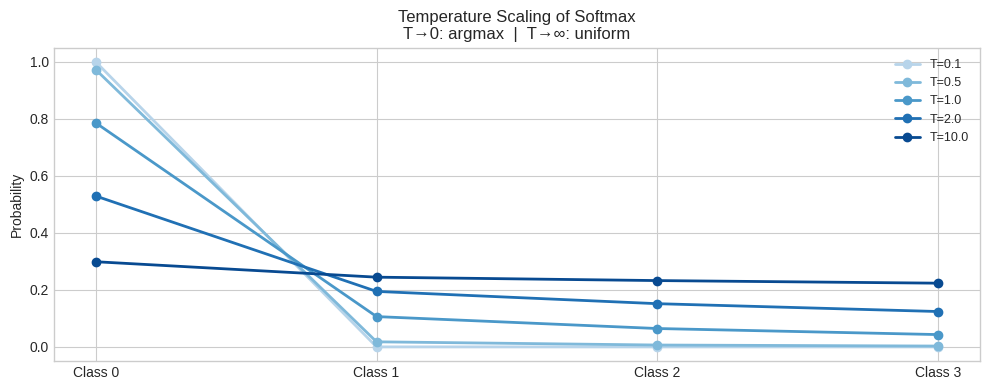

In [23]:
# Softmax: stability, temperature, and use
def softmax_naive(z):  return np.exp(z) / np.exp(z).sum()
def softmax_stable(z): e = np.exp(z - z.max()); return e / e.sum()

# Overflow demo
z_large = np.array([1000., 1001., 999.])
print('=== Numerical stability of softmax ===')
try:
    result = softmax_naive(z_large)
    print(f'Naive softmax on large values: {result}')
except:
    print('Naive softmax: overflow!')

try:
    import warnings; warnings.filterwarnings('ignore')
    result_naive = softmax_naive(z_large)
    if np.any(np.isnan(result_naive)):
        print('Naive softmax: NaN (overflow → 0/0)')
    else:
        print(f'Naive softmax: {result_naive}')
except:
    print('Naive softmax: exception')

result_stable = softmax_stable(z_large)
print(f'Stable softmax: {result_stable}  (correct!)')

# Temperature scaling
logits = np.array([3.0, 1.0, 0.5, 0.1])
temps  = [0.1, 0.5, 1.0, 2.0, 10.0]

fig, ax = plt.subplots(figsize=(10, 4))
x_pos   = np.arange(4)
colors_t = plt.cm.Blues(np.linspace(0.3, 0.9, len(temps)))

for T, color in zip(temps, colors_t):
    probs = softmax_stable(logits / T)
    ax.plot(x_pos, probs, 'o-', color=color, lw=2, label=f'T={T}')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Class {i}' for i in range(4)])
ax.set_title('Temperature Scaling of Softmax\nT→0: argmax  |  T→∞: uniform')
ax.set_ylabel('Probability')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 7. Comparison — All Activations Side by Side

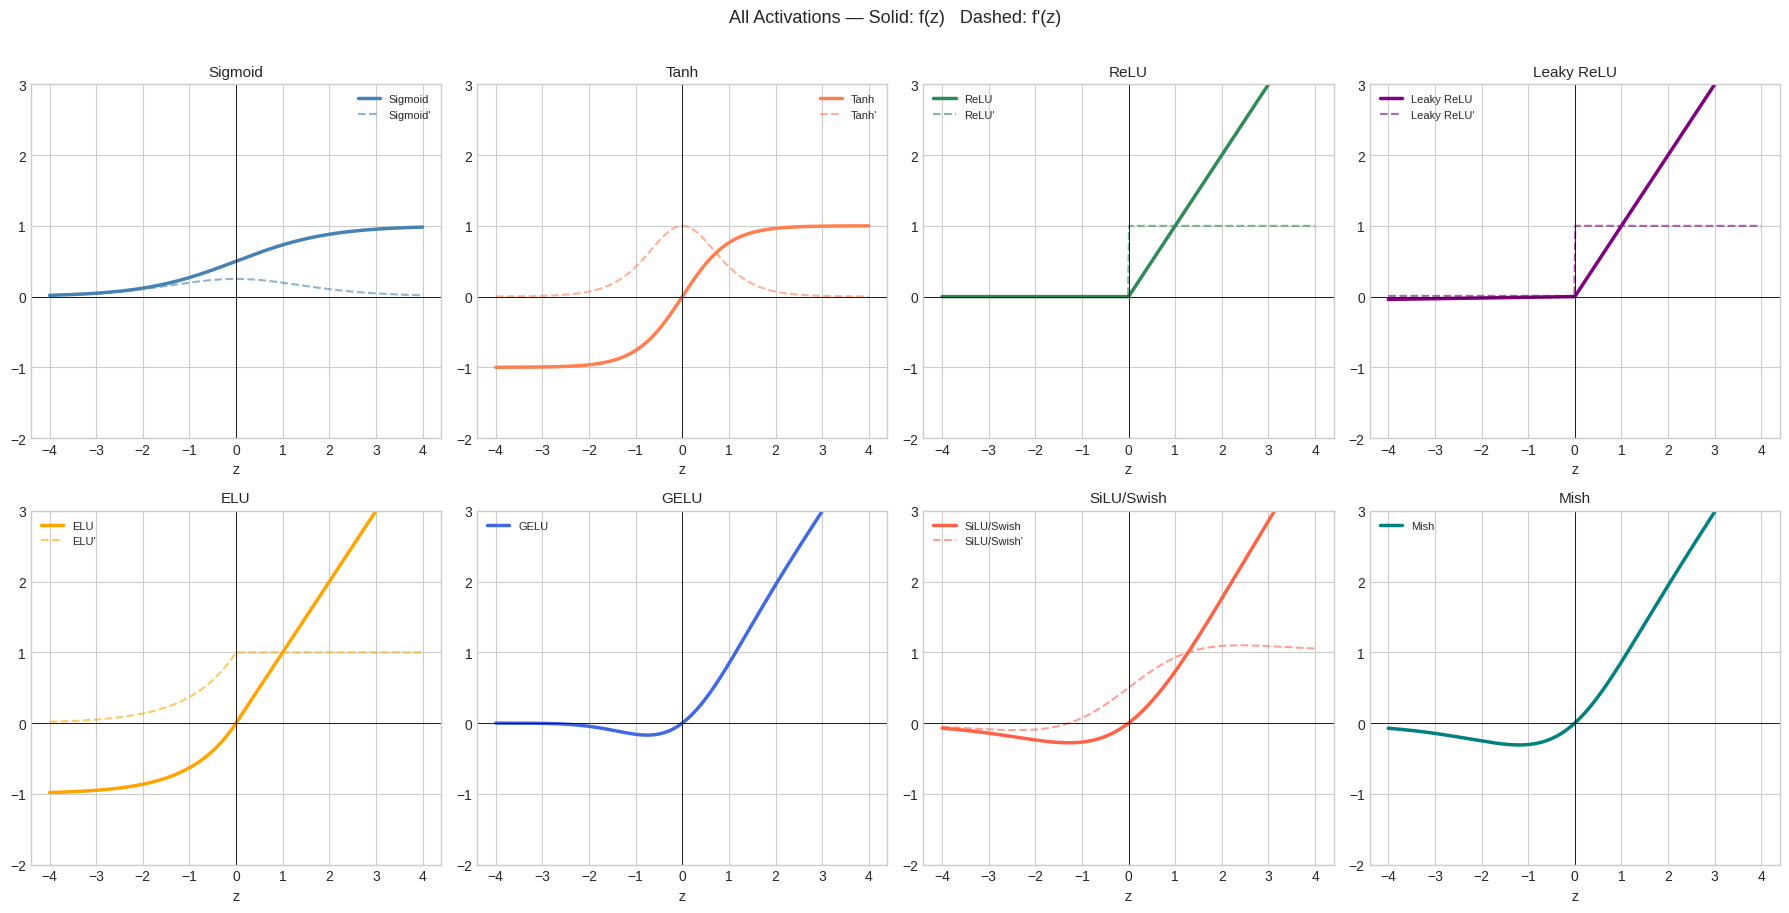

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

all_acts = [
    ('Sigmoid',    sigmoid,    sigmoid_prime,    'steelblue'),
    ('Tanh',       tanh,       tanh_prime,       'coral'),
    ('ReLU',       relu,       relu_prime,       'seagreen'),
    ('Leaky ReLU', leaky_relu, leaky_relu_prime, 'purple'),
    ('ELU',        elu,        elu_prime,        'orange'),
    ('GELU',       gelu,       None,             'royalblue'),
    ('SiLU/Swish', silu,       silu_prime,       'tomato'),
    ('Mish',       mish,       None,             'teal'),
]

for ax, (name, f, df, color) in zip(axes.ravel(), all_acts):
    y_vals = f(x_range)
    ax.plot(x_range, y_vals, color=color, lw=2.5, label=name)
    if df is not None:
        ax.plot(x_range, df(x_range), color=color, lw=1.5,
                linestyle='--', alpha=0.6, label=f"{name}'")
    ax.axhline(0, color='black', lw=0.6)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('z')
    ax.legend(fontsize=8)
    ax.set_ylim(-2, 3)

plt.suptitle('All Activations — Solid: f(z)   Dashed: f\'(z)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 8. Gradient Flow Experiments

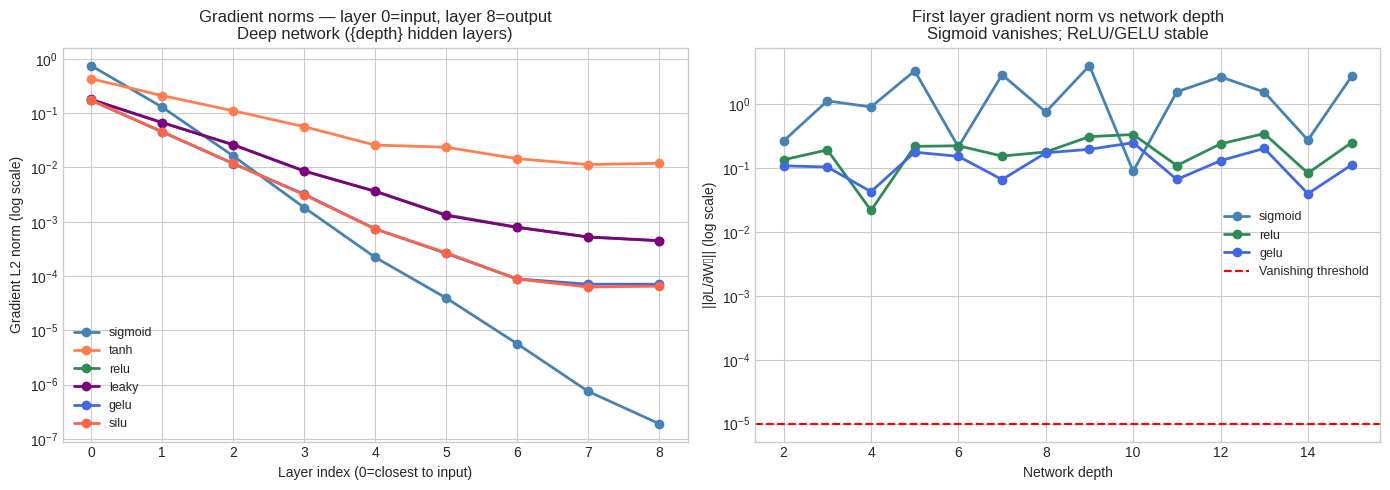

In [25]:
# Measure gradient norms at each layer for different activations
import torch.nn as nn

torch.manual_seed(42)

def build_deep_net(depth, activation):
    act_map = {
        'sigmoid': nn.Sigmoid(),
        'tanh':    nn.Tanh(),
        'relu':    nn.ReLU(),
        'leaky':   nn.LeakyReLU(0.01),
        'gelu':    nn.GELU(),
        'silu':    nn.SiLU(),
    }
    layers = []
    for _ in range(depth):
        layers += [nn.Linear(32, 32), act_map[activation]]
    layers += [nn.Linear(32, 1)]
    return nn.Sequential(*layers)

def measure_gradient_norms(net, x, y, criterion=nn.MSELoss()):
    net.zero_grad()
    loss = criterion(net(x), y)
    loss.backward()
    norms = []
    for name, param in net.named_parameters():
        if 'weight' in name and param.grad is not None:
            norms.append(param.grad.norm().item())
    return norms

depth = 8
x_gf  = torch.randn(64, 32)
y_gf  = torch.randn(64, 1)

act_names = ['sigmoid', 'tanh', 'relu', 'leaky', 'gelu', 'silu']
colors_gf = ['steelblue', 'coral', 'seagreen', 'purple', 'royalblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for act_name, color in zip(act_names, colors_gf):
    torch.manual_seed(1)
    net_gf   = build_deep_net(depth, act_name)
    norms_gf = measure_gradient_norms(net_gf, x_gf, y_gf)
    # norms[0] = last layer (closest to loss), norms[-1] = first layer
    axes[0].semilogy(range(len(norms_gf)), norms_gf[::-1],
                     'o-', color=color, lw=2, label=act_name)

axes[0].set_title(f'Gradient norms — layer 0=input, layer {depth}=output\n'
                   'Deep network ({depth} hidden layers)')
axes[0].set_xlabel('Layer index (0=closest to input)')
axes[0].set_ylabel('Gradient L2 norm (log scale)')
axes[0].legend(fontsize=9)

# Vary depth
for act_name, color in zip(['sigmoid', 'relu', 'gelu'], ['steelblue', 'seagreen', 'royalblue']):
    depths_gf  = range(2, 16)
    first_layer_norms = []
    for d in depths_gf:
        torch.manual_seed(1)
        net_d = build_deep_net(d, act_name)
        norms = measure_gradient_norms(net_d, x_gf, y_gf)
        first_layer_norms.append(norms[-1])  # first linear layer gradient
    axes[1].semilogy(list(depths_gf), first_layer_norms,
                     'o-', color=color, lw=2, label=act_name)

axes[1].set_title('First layer gradient norm vs network depth\nSigmoid vanishes; ReLU/GELU stable')
axes[1].set_xlabel('Network depth'); axes[1].set_ylabel('||∂L/∂W₁|| (log scale)')
axes[1].axhline(1e-5, color='red', lw=1.5, linestyle='--', label='Vanishing threshold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 9. The Dead Neuron Problem

A **dead ReLU neuron** is one that outputs 0 for every input in the dataset. Because $\text{ReLU}'(z) = 0$ when $z \leq 0$, the neuron receives no gradient and can never recover — it is permanently dead.

**Causes:**
1. **Large learning rate** — a big gradient step drives the neuron's pre-activation permanently negative
2. **Large negative bias initialisation** — the neuron starts dead
3. **Bad weight initialisation** — very large initial weights cause large pre-activations

**Detection:**
```python
# Check fraction of dead neurons
activations = F.relu(layer(X))
dead_fraction = (activations == 0).float().mean()
```

**Fixes:**
- Use Leaky ReLU, ELU, GELU, or SiLU instead of ReLU
- Use He initialisation (default in PyTorch `nn.Linear` + `nn.ReLU`)
- Use a smaller learning rate
- Add batch normalisation before the activation


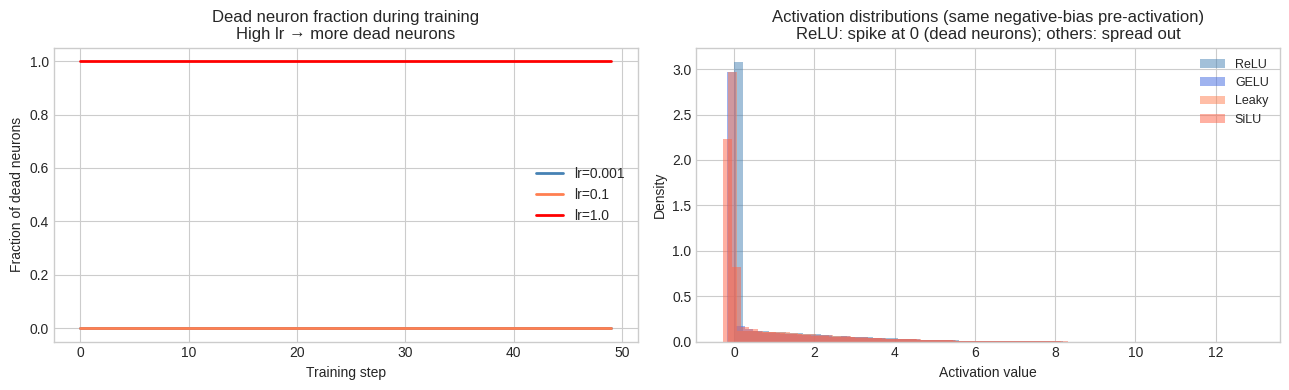

Dead neuron fraction: ReLU=0.000  Leaky=0.000


In [26]:
# Demonstrate dead neurons and measure dead fraction
torch.manual_seed(0)

class DeadNeuronNet(nn.Module):
    def __init__(self, lr_scale=1.0):
        super().__init__()
        self.fc1 = nn.Linear(20, 256)
        self.fc2 = nn.Linear(256, 1)
        # Simulate bad init: large negative bias
        with torch.no_grad():
            self.fc1.bias.fill_(-lr_scale * 3.0)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        return self.fc2(h), h

def measure_dead_neurons(net, X, threshold=1e-6):
    net.eval()
    with torch.no_grad():
        _, h = net(X)
    # A neuron is dead if its activation is 0 for ALL inputs
    dead = (h.max(dim=0).values < threshold)
    return dead.float().mean().item()

X_dead = torch.randn(1000, 20)
y_dead = torch.randn(1000, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for lr, color in [(0.001, 'steelblue'), (0.1, 'coral'), (1.0, 'red')]:
    net_d   = DeadNeuronNet(lr_scale=lr)
    opt_d   = optim.SGD(net_d.parameters(), lr=lr)
    dead_fracs = []

    for step in range(50):
        dead_fracs.append(measure_dead_neurons(net_d, X_dead))
        net_d.train()
        opt_d.zero_grad()
        pred, _ = net_d(X_dead)
        F.mse_loss(pred, y_dead).backward()
        opt_d.step()

    axes[0].plot(dead_fracs, color=color, lw=2, label=f'lr={lr}')

axes[0].set_title('Dead neuron fraction during training\nHigh lr → more dead neurons')
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('Fraction of dead neurons')
axes[0].legend()

# Compare activations: ReLU vs GELU vs Leaky
X_test_act = torch.randn(500, 32)
acts_compare = [
    ('ReLU',     lambda x: F.relu(x)),
    ('GELU',     lambda x: F.gelu(x)),
    ('Leaky',    lambda x: F.leaky_relu(x, 0.01)),
    ('SiLU',     lambda x: F.silu(x)),
]

# Get pre-activations
W_act = torch.randn(64, 32) * 0.5
b_act = torch.randn(64) - 1.0   # slightly negative bias to create 'almost dead' scenario
z_act = X_test_act @ W_act.T + b_act

for (name, f), color in zip(acts_compare, ['steelblue','royalblue','coral','tomato']):
    out = f(z_act).detach().numpy().ravel()
    axes[1].hist(out, bins=60, alpha=0.5, color=color, label=name, density=True)

axes[1].set_title('Activation distributions (same negative-bias pre-activation)\n'
                   'ReLU: spike at 0 (dead neurons); others: spread out')
axes[1].set_xlabel('Activation value'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

dead_relu  = (F.relu(z_act).max(dim=0).values < 1e-6).float().mean().item()
dead_leaky = (F.leaky_relu(z_act,0.01).abs().max(dim=0).values < 1e-6).float().mean().item()
print(f'Dead neuron fraction: ReLU={dead_relu:.3f}  Leaky={dead_leaky:.3f}')


## 10. PyTorch Implementation and Custom Activations

In [27]:
# All built-in PyTorch activations
print('=== PyTorch activation functions ===')

x_pt = torch.tensor([-2., -1., 0., 1., 2.])

activations_pt = {
    'F.relu':          F.relu(x_pt),
    'F.leaky_relu':    F.leaky_relu(x_pt, 0.01),
    'F.elu':           F.elu(x_pt),
    'F.gelu':          F.gelu(x_pt),
    'F.silu':          F.silu(x_pt),
    'torch.sigmoid':   torch.sigmoid(x_pt),
    'torch.tanh':      torch.tanh(x_pt),
    'F.softmax (dim)': F.softmax(x_pt, dim=0),
    'F.log_softmax':   F.log_softmax(x_pt, dim=0),
    'F.softplus':      F.softplus(x_pt),
}

print(f'Input: {x_pt.numpy()}')
print()
for name, out in activations_pt.items():
    print(f'{name:<25}: {out.numpy().round(4)}')


=== PyTorch activation functions ===
Input: [-2. -1.  0.  1.  2.]

F.relu                   : [0. 0. 0. 1. 2.]
F.leaky_relu             : [-0.02 -0.01  0.    1.    2.  ]
F.elu                    : [-0.8647 -0.6321  0.      1.      2.    ]
F.gelu                   : [-0.0455 -0.1587  0.      0.8413  1.9545]
F.silu                   : [-0.2384 -0.2689  0.      0.7311  1.7616]
torch.sigmoid            : [0.1192 0.2689 0.5    0.7311 0.8808]
torch.tanh               : [-0.964  -0.7616  0.      0.7616  0.964 ]
F.softmax (dim)          : [0.0117 0.0317 0.0861 0.2341 0.6364]
F.log_softmax            : [-4.4519 -3.4519 -2.4519 -1.4519 -0.4519]
F.softplus               : [0.1269 0.3133 0.6931 1.3133 2.1269]


In [28]:
# Custom activation as nn.Module — the right way to add a new activation
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class Swish(nn.Module):
    def __init__(self, trainable_beta=False):
        super().__init__()
        if trainable_beta:
            self.beta = nn.Parameter(torch.ones(1))
        else:
            self.beta = 1.0

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

# Test custom activations
x_custom = torch.randn(4, 8, requires_grad=True)

mish_act  = Mish()
swish_act = Swish(trainable_beta=True)

out_mish  = mish_act(x_custom)
out_swish = swish_act(x_custom)

# Verify gradients flow through
out_mish.sum().backward()
print(f'Mish output shape:  {out_mish.shape}  requires_grad: {out_mish.requires_grad}')
print(f'Swish output shape: {out_swish.shape}')
print(f'Gradient flows through Mish: {x_custom.grad is not None}')

# Training comparison: which activation learns best?
from sklearn.datasets import make_moons
X_m, y_m = make_moons(n_samples=500, noise=0.2, random_state=42)
X_m = torch.tensor(X_m, dtype=torch.float32)
y_m = torch.tensor(y_m, dtype=torch.long)

def train_with_activation(activation_module, epochs=300, lr=1e-2):
    torch.manual_seed(42)
    net = nn.Sequential(
        nn.Linear(2, 32), activation_module,
        nn.Linear(32, 32), activation_module,
        nn.Linear(32, 2)
    )
    # Note: using same activation instance twice is fine for stateless activations
    opt  = optim.Adam(net.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        opt.zero_grad(); crit(net(X_m), y_m).backward(); opt.step()
    with torch.no_grad():
        acc = (net(X_m).argmax(1) == y_m).float().mean().item()
    return acc

act_modules = [
    ('ReLU',    nn.ReLU()),
    ('Tanh',    nn.Tanh()),
    ('GELU',    nn.GELU()),
    ('SiLU',    nn.SiLU()),
    ('Mish',    Mish()),
    ('Leaky',   nn.LeakyReLU(0.01)),
]

print('\nAccuracy on make_moons (500 samples, 300 epochs):')
for name, module in act_modules:
    acc = train_with_activation(module)
    bar = '█' * int(acc * 30)
    print(f'  {name:<10} {bar:<30} {acc:.4f}')


Mish output shape:  torch.Size([4, 8])  requires_grad: True
Swish output shape: torch.Size([4, 8])
Gradient flows through Mish: True

Accuracy on make_moons (500 samples, 300 epochs):
  ReLU       █████████████████████████████  0.9880
  Tanh       █████████████████████████████  0.9860
  GELU       █████████████████████████████  0.9840
  SiLU       █████████████████████████████  0.9800
  Mish       █████████████████████████████  0.9820
  Leaky      █████████████████████████████  0.9900


## 11. Debugging Section

In [29]:
# Bug 1: Applying sigmoid before BCEWithLogitsLoss
print('=== Bug 1: sigmoid output + BCEWithLogitsLoss = double sigmoid ===')
x_b = torch.randn(10, 1)
y_b = torch.randint(0, 2, (10, 1)).float()
logits_b = torch.randn(10, 1, requires_grad=True)

# Correct
loss_correct = F.binary_cross_entropy_with_logits(logits_b, y_b)

# Wrong: apply sigmoid first
probs_b = torch.sigmoid(logits_b)
loss_wrong = F.binary_cross_entropy_with_logits(probs_b, y_b)  # double sigmoid!

print(f'Correct (logits → BCEWithLogitsLoss):        loss = {loss_correct.item():.4f}')
print(f'Wrong (sigmoid(logits) → BCEWithLogitsLoss): loss = {loss_wrong.item():.4f}')
print(f'The wrong version applies sigmoid twice, compressing gradients.')
print()
print('Rule: BCEWithLogitsLoss expects raw logits, NOT sigmoid output.')
print('CrossEntropyLoss expects raw logits, NOT softmax output.')


=== Bug 1: sigmoid output + BCEWithLogitsLoss = double sigmoid ===
Correct (logits → BCEWithLogitsLoss):        loss = 1.1224
Wrong (sigmoid(logits) → BCEWithLogitsLoss): loss = 0.8503
The wrong version applies sigmoid twice, compressing gradients.

Rule: BCEWithLogitsLoss expects raw logits, NOT sigmoid output.
CrossEntropyLoss expects raw logits, NOT softmax output.


In [30]:
# Bug 2: Using softmax in intermediate layers
print('=== Bug 2: Softmax in hidden layers — kills gradient flow ===')

class SoftmaxHiddenNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 16)
        self.fc2 = nn.Linear(16, 4)

    def forward(self, x):
        # WRONG: softmax in hidden layer
        h = F.softmax(self.fc1(x), dim=-1)  # all values sum to 1, tiny gradients
        return self.fc2(h)

class ReLUHiddenNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 16)
        self.fc2 = nn.Linear(16, 4)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

X_bug = torch.randn(100, 8)
y_bug = torch.randint(0, 4, (100,))

for NetClass, name in [(SoftmaxHiddenNet, 'Softmax hidden'), (ReLUHiddenNet, 'ReLU hidden')]:
    torch.manual_seed(0)
    net_b = NetClass()
    opt_b = optim.Adam(net_b.parameters(), lr=1e-2)
    losses_b = []
    for _ in range(200):
        opt_b.zero_grad()
        loss_b = F.cross_entropy(net_b(X_bug), y_bug)
        loss_b.backward()
        opt_b.step()
        losses_b.append(loss_b.item())
    print(f'{name}: initial loss={losses_b[0]:.4f}  final loss={losses_b[-1]:.4f}')

print('\nSoftmax in hidden layers: gradients become tiny because softmax output is nearly uniform.')
print('Use softmax ONLY at the output layer for multi-class classification.')


=== Bug 2: Softmax in hidden layers — kills gradient flow ===
Softmax hidden: initial loss=1.3814  final loss=0.4248
ReLU hidden: initial loss=1.3952  final loss=0.1769

Softmax in hidden layers: gradients become tiny because softmax output is nearly uniform.
Use softmax ONLY at the output layer for multi-class classification.


In [39]:
# Bug 3: Wrong activation for regression — sigmoid bounds predictions
print('=== Bug 3: Sigmoid output for regression — predictions bounded to (0,1) ===')

# Data with targets outside [0, 1]
X_reg = torch.randn(200, 4)
y_reg = torch.randn(200, 1) * 5  # targets roughly outside [0, 1]

class BoundedRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(4, 1)  # register parameters once

    def forward(self, x):
        return torch.sigmoid(self.fc(x))  # wrong for unbounded regression (intentional)

class UnboundedRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x):
        return self.net(x)  # correct: linear output

torch.manual_seed(0)
results_reg = {}
for name, NetCls in [('Sigmoid output (wrong)', BoundedRegressor),
                      ('Linear output (correct)', UnboundedRegressor)]:
    net_r = NetCls()
    opt_r = optim.Adam(net_r.parameters(), lr=1e-2)
    for _ in range(300):
        opt_r.zero_grad()
        F.mse_loss(net_r(X_reg), y_reg).backward()
        opt_r.step()
    with torch.no_grad():
        preds = net_r(X_reg)
        mse = F.mse_loss(preds, y_reg).item()
        pred_range = f'[{preds.min().item():.2f}, {preds.max().item():.2f}]'
    print(f'{name}:')
    print(f'  MSE={mse:.2f}  prediction range={pred_range}')

print('\nRule: for regression, use NO activation (linear output) unless you know the target range.')


=== Bug 3: Sigmoid output for regression — predictions bounded to (0,1) ===
Sigmoid output (wrong):
  MSE=24.47  prediction range=[0.00, 1.00]
Linear output (correct):
  MSE=15.98  prediction range=[-8.05, 12.27]

Rule: for regression, use NO activation (linear output) unless you know the target range.


## 12. Exercises

**Exercise 1:** Implement **GELU from scratch** using only NumPy (no scipy.special). Use the approximation formula:

$$\text{GELU}(z) \approx 0.5z\left(1 + \tanh\left[\sqrt{\frac{2}{\pi}}(z + 0.044715z^3)\right]\right)$$

Then derive and implement its derivative analytically. Verify with numerical gradient checking, and verify it matches `F.gelu()` on a random input tensor.


In [32]:
# Your code here


In [33]:
# Solution
def gelu_approx_scratch(z):
    c = np.sqrt(2 / np.pi)
    return 0.5 * z * (1 + np.tanh(c * (z + 0.044715 * z**3)))

def gelu_approx_prime(z):
    c  = np.sqrt(2 / np.pi)
    inner = c * (z + 0.044715 * z**3)
    t  = np.tanh(inner)
    dt = 1 - t**2   # tanh derivative
    # Chain rule: d/dz [0.5z(1+tanh(inner))]
    # = 0.5(1+tanh) + 0.5z * tanh' * d(inner)/dz
    d_inner = c * (1 + 3 * 0.044715 * z**2)
    return 0.5 * (1 + t) + 0.5 * z * dt * d_inner

# Verify against numerical gradient
z_test_gelu = np.linspace(-3, 3, 200)
grad_analytical = gelu_approx_prime(z_test_gelu)
grad_numerical  = np.array([
    (gelu_approx_scratch(z+1e-5) - gelu_approx_scratch(z-1e-5)) / (2e-5)
    for z in z_test_gelu
])

max_err = np.max(np.abs(grad_analytical - grad_numerical))
print(f'Max gradient error (analytical vs numerical): {max_err:.2e}  ✓' if max_err < 1e-5 else f'Max error: {max_err:.2e}')

# Verify against PyTorch F.gelu
x_torch = torch.linspace(-3, 3, 200)
pt_gelu = F.gelu(x_torch).numpy()
np_gelu = gelu_approx_scratch(x_torch.numpy())
max_pt_err = np.max(np.abs(pt_gelu - np_gelu))
print(f'Max error vs F.gelu:                          {max_pt_err:.2e}  '
      + ('✓' if max_pt_err < 1e-3 else '✗'))
print('(Small difference because PyTorch uses exact GELU, we used approximation)')


Max gradient error (analytical vs numerical): 3.04e-11  ✓
Max error vs F.gelu:                          4.73e-04  ✓
(Small difference because PyTorch uses exact GELU, we used approximation)


**Exercise 2:** Build an experiment showing the **dying ReLU problem** and its fix. Train two identical 5-layer networks on the same task:
- Network A: ReLU activations with large learning rate (lr=1.0)
- Network B: Leaky ReLU (α=0.01) with same learning rate

At each epoch, measure and plot:
1. Training loss
2. Fraction of dead neurons in each hidden layer

Show that Network A has dead neurons and Network B does not.


In [34]:
# Your code here


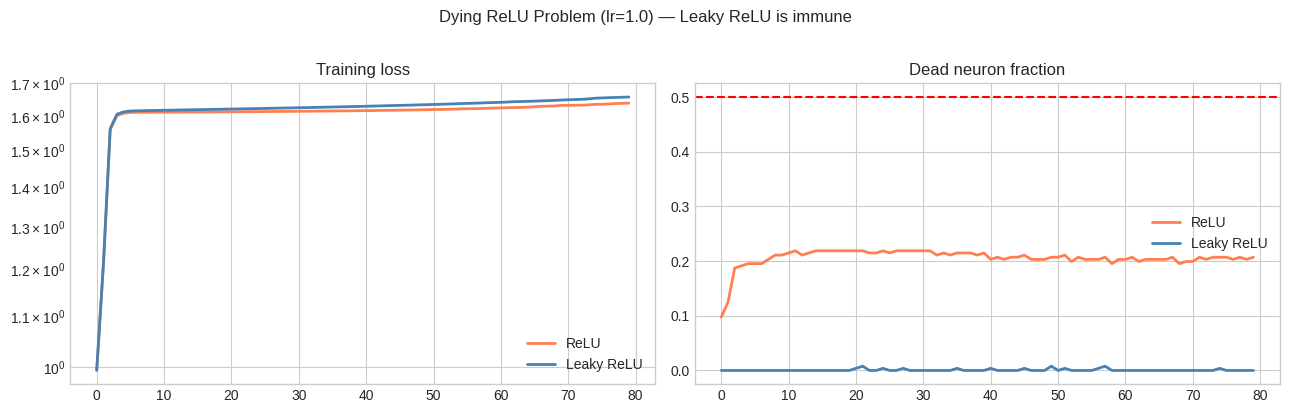

In [35]:
# Solution
torch.manual_seed(0)

class DeepReLUNet(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(20, 64), nn.Linear(64, 64),
            nn.Linear(64, 64), nn.Linear(64, 64),
            nn.Linear(64, 1)
        ])
        self.act = activation
        self.activations_cache = []

    def forward(self, x):
        self.activations_cache = []
        for i, layer in enumerate(self.layers[:-1]):
            x = self.act(layer(x))
            self.activations_cache.append(x.detach())
        return self.layers[-1](x)

X_dy = torch.randn(200, 20)
y_dy = torch.randn(200, 1)

results = {}
for name, act in [('ReLU', nn.ReLU()), ('Leaky ReLU', nn.LeakyReLU(0.01))]:
    torch.manual_seed(42)
    net_dy = DeepReLUNet(act)
    opt_dy = optim.SGD(net_dy.parameters(), lr=1.0)  # large lr!
    epoch_losses, epoch_dead = [], []

    for ep in range(80):
        net_dy.train()
        opt_dy.zero_grad()
        loss_dy = F.mse_loss(net_dy(X_dy), y_dy)
        loss_dy.backward(); opt_dy.step()
        epoch_losses.append(loss_dy.item())

        net_dy.eval()
        with torch.no_grad(): _ = net_dy(X_dy)
        dead_fracs = [
            (a.max(dim=0).values.abs() < 1e-6).float().mean().item()
            for a in net_dy.activations_cache
        ]
        epoch_dead.append(np.mean(dead_fracs))
    results[name] = (epoch_losses, epoch_dead)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, (losses, dead) in results.items():
    color = 'coral' if 'ReLU' == name else 'steelblue'
    axes[0].semilogy(losses, color=color, lw=2, label=name)
    axes[1].plot(dead,    color=color, lw=2, label=name)

axes[0].set_title('Training loss'); axes[0].legend()
axes[1].set_title('Dead neuron fraction'); axes[1].legend()
axes[1].axhline(0.5, color='red', lw=1.5, linestyle='--', label='50% dead threshold')
plt.suptitle('Dying ReLU Problem (lr=1.0) — Leaky ReLU is immune', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**Exercise 3:** Implement a **custom parametric activation** as an `nn.Module`:

$$\text{PAU}(z; a, b, c) = \frac{a + bz}{1 + |cz|}$$

where $a$, $b$, $c$ are learnable scalar parameters initialised to $a=0, b=1, c=0.01$. This is a simple rational function approximation. Train it on a regression task and visualise how the activation shape changes during training.


In [36]:
# Your code here


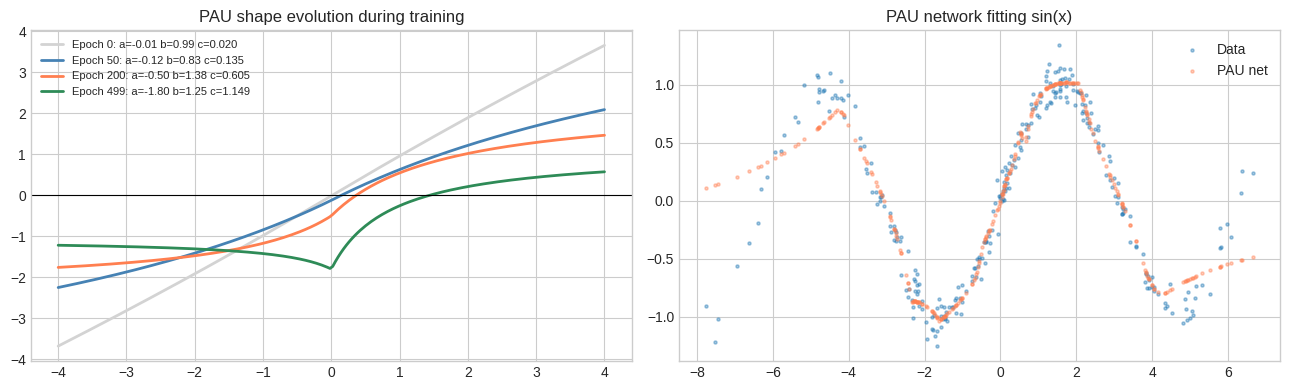

In [37]:
# Solution
class PAU(nn.Module):
    """Parametric Activation Unit: (a + bz) / (1 + |cz|)"""
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(0.0))
        self.b = nn.Parameter(torch.tensor(1.0))
        self.c = nn.Parameter(torch.tensor(0.01))

    def forward(self, z):
        return (self.a + self.b * z) / (1 + torch.abs(self.c * z) + 1e-6)

# Track activation shape at different training stages
torch.manual_seed(42)
X_pau = torch.randn(300, 1) * 3
y_pau = torch.sin(X_pau) + 0.1 * torch.randn_like(X_pau)

net_pau = nn.Sequential(nn.Linear(1, 16), PAU(), nn.Linear(16, 1))
opt_pau = optim.Adam(net_pau.parameters(), lr=1e-2)

snapshots = {}  # epoch -> activation params
for ep in range(500):
    opt_pau.zero_grad()
    F.mse_loss(net_pau(X_pau), y_pau).backward()
    opt_pau.step()
    if ep in [0, 50, 200, 499]:
        pau_mod = net_pau[1]
        snapshots[ep] = (pau_mod.a.item(), pau_mod.b.item(), pau_mod.c.item())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
z_vis = torch.linspace(-4, 4, 200)
colors_pau = ['lightgray', 'steelblue', 'coral', 'seagreen']

for (ep, (a, b, c)), color in zip(snapshots.items(), colors_pau):
    y_vis = (a + b*z_vis) / (1 + torch.abs(c*z_vis) + 1e-6)
    axes[0].plot(z_vis.numpy(), y_vis.detach().numpy(), color=color, lw=2,
                 label=f'Epoch {ep}: a={a:.2f} b={b:.2f} c={c:.3f}')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('PAU shape evolution during training'); axes[0].legend(fontsize=8)

# Final predictions
with torch.no_grad():
    y_pred_pau = net_pau(X_pau)
axes[1].scatter(X_pau.numpy(), y_pau.numpy(), s=5, alpha=0.4, label='Data')
axes[1].scatter(X_pau.numpy(), y_pred_pau.numpy(), s=5, alpha=0.4, color='coral', label='PAU net')
axes[1].set_title('PAU network fitting sin(x)')
axes[1].legend()
plt.tight_layout()
plt.show()


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
